PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("=" * 70)
print("DATASET BREAST CANCER WISCONSIN (DIAGNOSTIC)")
print("=" * 70)

print("\n5 DATA TERATAS:")
display(X.head())

print("\nDIMENSI DATA:")
print(f"Jumlah observasi : {X.shape[0]}")
print(f"Jumlah variabel  : {X.shape[1]}")

print("\nUNIT OBSERVASI:")
print("Unit observasi adalah satu pasien/satu sampel tumor payudara.")

print("\nTARGET / DIAGNOSIS:")
print("0 =", data.target_names[0])
print("1 =", data.target_names[1])

print("\nVARIABEL YANG DIGUNAKAN:")
for i, var in enumerate(X.columns, 1):
    print(f"{i:2}. {var}")

DATASET BREAST CANCER WISCONSIN (DIAGNOSTIC)

5 DATA TERATAS:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



DIMENSI DATA:
Jumlah observasi : 569
Jumlah variabel  : 30

UNIT OBSERVASI:
Unit observasi adalah satu pasien/satu sampel tumor payudara.

TARGET / DIAGNOSIS:
0 = malignant
1 = benign

VARIABEL YANG DIGUNAKAN:
 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


In [3]:
print("MISSING VALUES")

missing = X.isnull().sum()

print(missing)

print("\nTotal missing values:", missing.sum())

if missing.sum() == 0:
    print("Kesimpulan: tidak terdapat missing values.")
else:
    print("Kesimpulan: terdapat missing values.")

MISSING VALUES
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Total missing values: 0
Kesimpulan: tidak terdapat missing values.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Data setelah standardization:")
display(X_scaled_df.head())

Data setelah standardization:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [5]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
eigenvalues = pca_full.explained_variance_

pca_table = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(explained_variance)+1)],
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative (%)": cumulative_variance * 100
})

print("\nEXPLAINED VARIANCE:")
display(pca_table)


EXPLAINED VARIANCE:


,PC,Eigenvalue,Explained Variance Ratio,Explained Variance (%),Cumulative (%)
0,PC1,13.304991,0.442720,44.272026,44.272026
1,PC2,5.701375,0.189712,18.971182,63.243208
2,PC3,2.822910,0.093932,9.393163,72.636371
3,PC4,1.984128,0.066021,6.602135,79.238506
4,PC5,1.651633,0.054958,5.495768,84.734274
5,PC6,1.209482,0.040245,4.024522,88.758796
6,PC7,0.676409,0.022507,2.250734,91.009530
7,PC8,0.477456,0.015887,1.588724,92.598254
8,PC9,0.417629,0.013896,1.389649,93.987903
9,PC10,0.351311,0.011690,1.168978,95.156881


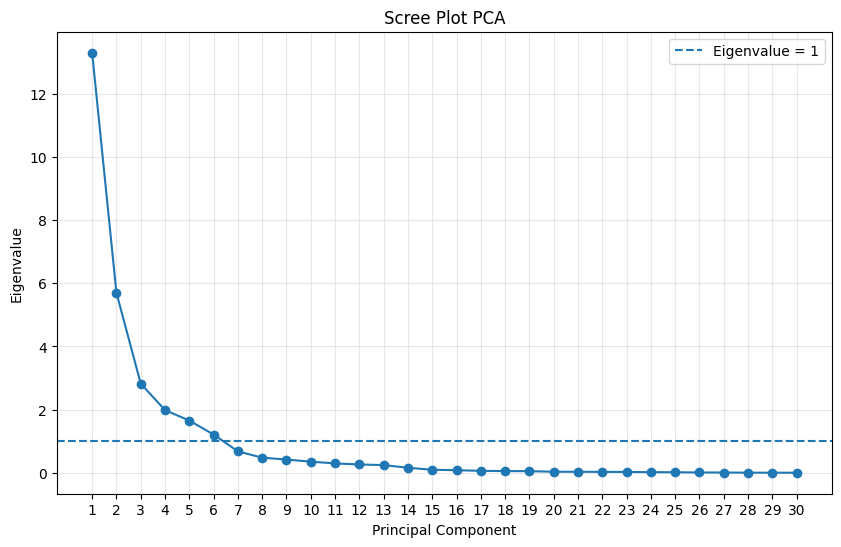

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Eigenvalue = 1"
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot PCA")
plt.xticks(range(1, 31))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
n_pc_kaiser = np.sum(eigenvalues > 1)

n_pc_80 = np.argmax(cumulative_variance >= 0.80) + 1

print("\nJUMLAH PC BERDASARKAN KRITERIA:")
print(f"Eigenvalue > 1 : {n_pc_kaiser} PC")
print(f"Cumulative >= 80% : {n_pc_80} PC")


JUMLAH PC BERDASARKAN KRITERIA:
Eigenvalue > 1 : 6 PC
Cumulative >= 80% : 5 PC


In [8]:
n_pc = n_pc_kaiser

pca = PCA(n_components=n_pc)
X_pca = pca.fit_transform(X_scaled)

print(f"\nJumlah PC yang digunakan: {n_pc}")

pca_selected_table = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, n_pc + 1)],
    "Explained Variance (%)":
        pca.explained_variance_ratio_ * 100,
    "Cumulative (%)":
        np.cumsum(pca.explained_variance_ratio_) * 100
})

display(pca_selected_table)


Jumlah PC yang digunakan: 6


,PC,Explained Variance (%),Cumulative (%)
0,PC1,44.272026,44.272026
1,PC2,18.971182,63.243208
2,PC3,9.393163,72.636371
3,PC4,6.602135,79.238506
4,PC5,5.495768,84.734274
5,PC6,4.024522,88.758796


In [9]:
# Loadings PCA = eigenvector x sqrt(eigenvalue)  (korelasi antara variabel dan PC)
loadings_df = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, n_pc + 1)]
)

In [10]:
pc12_loadings = loadings_df[["PC1", "PC2"]]

print("\nLOADINGS PC1 DAN PC2:")
display(
    pc12_loadings.sort_values(
        by="PC1",
        key=abs,
        ascending=False
    )
)


LOADINGS PC1 DAN PC2:


,PC1,PC2
mean concave points,0.951490,-0.083016
mean concavity,0.942542,0.143660
worst concave points,0.915132,-0.019716
mean compactness,0.872817,0.362680
worst perimeter,0.863167,-0.477261
worst concavity,0.834453,0.233914
worst radius,0.831641,-0.524987
mean perimeter,0.829965,-0.513800
worst area,0.820238,-0.523759
mean area,0.806101,-0.551755


FAKTOR ANALISIS

In [11]:
# Uji kelayakan Analisis Faktor
chi_square, p_value = calculate_bartlett_sphericity(X_scaled_df)
kmo_per_var, kmo_total = calculate_kmo(X_scaled_df)

print(f"Bartlett's test : chi-square = {chi_square:.2f}, p-value = {p_value:.4f}")
print(f"KMO keseluruhan : {kmo_total:.3f}")

Bartlett's test : chi-square = 39362.12, p-value = 0.0000
KMO keseluruhan : 0.832


c:\Users\ASTHAGINA DELIA P\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [12]:
fa_test = FactorAnalyzer(
    rotation=None,
    method="minres"
)

fa_test.fit(X_scaled_df)

fa_eigenvalues, _ = fa_test.get_eigenvalues()

fa_eigen_table = pd.DataFrame({
    "Factor": range(1, len(fa_eigenvalues) + 1),
    "Eigenvalue": fa_eigenvalues
})

print("\nEIGENVALUE FACTOR ANALYSIS:")
display(fa_eigen_table)

n_factor_kaiser = np.sum(fa_eigenvalues > 1)

print(
    f"\nJumlah factor berdasarkan Kaiser "
    f"(eigenvalue > 1): {n_factor_kaiser}"
)


EIGENVALUE FACTOR ANALYSIS:


,Factor,Eigenvalue
0,1,13.281608
1,2,5.691355
2,3,2.817949
3,4,1.980640
4,5,1.648731
5,6,1.207357
6,7,0.675220
7,8,0.476617
8,9,0.416895
9,10,0.350693



Jumlah factor berdasarkan Kaiser (eigenvalue > 1): 6


In [13]:
n_factor = n_factor_kaiser

fa = FactorAnalyzer(
    n_factors=n_factor,
    rotation="varimax",
    method="minres"
)

fa.fit(X_scaled_df)

fa_loadings = pd.DataFrame(
    fa.loadings_,
    index=X.columns,
    columns=[f"Factor{i}" for i in range(1, n_factor + 1)]
)

print(f"\nFACTOR LOADINGS ({n_factor} FACTORS):")
display(fa_loadings)


FACTOR LOADINGS (6 FACTORS):


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6
mean radius,0.955626,0.056451,-0.014287,-0.168382,0.101762,0.018811
mean texture,0.255512,0.078682,-0.026154,0.096211,0.860222,0.006695
mean perimeter,0.955334,0.097439,0.016640,-0.158442,0.103484,0.035256
mean area,0.970989,0.053349,-0.007131,-0.091867,0.088514,0.004348
mean smoothness,0.202996,0.180879,0.809162,0.212796,-0.100938,0.171657
mean compactness,0.472758,0.601982,0.490245,-0.020797,0.079250,0.269827
mean concavity,0.658361,0.588161,0.310553,-0.013579,0.111966,0.172569
mean concave points,0.810901,0.340175,0.348497,-0.017527,0.077629,0.149176
mean symmetry,0.164550,0.280907,0.364989,0.193745,-0.017114,0.604787
mean fractal dimension,-0.294971,0.579556,0.556485,0.212812,-0.066236,0.190974


In [14]:
for factor in fa_loadings.columns:

    temp = fa_loadings[factor].sort_values(
        key=abs,
        ascending=False
    )

    print(f"\n{factor}:")
    display(temp.head(7))


Factor1:


mean area          0.970989
mean radius        0.955626
mean perimeter     0.955334
worst radius       0.954574
worst area         0.953191
worst perimeter    0.951022
area error         0.857298
Name: Factor1, dtype: float64


Factor2:


compactness error          0.895143
concavity error            0.845511
fractal dimension error    0.822124
concave points error       0.687770
worst concavity            0.612047
mean compactness           0.601982
worst fractal dimension    0.596042
Name: Factor2, dtype: float64


Factor3:


...

smoothness error     0.627637
texture error        0.618750
symmetry error       0.580153
radius error         0.431248
perimeter error      0.410883
worst compactness   -0.330342
worst concavity     -0.309468
Name: Factor4, dtype: float64


Factor5:


worst texture        0.983119
mean texture         0.860222
texture error        0.410387
worst compactness    0.222126
worst concavity      0.210432
worst perimeter      0.151665
worst radius         0.148724
Name: Factor5, dtype: float64


Factor6:


worst symmetry             0.904544
mean symmetry              0.604787
symmetry error             0.537293
worst compactness          0.306945
mean compactness           0.269827
worst fractal dimension    0.229497
worst concavity            0.221998
Name: Factor6, dtype: float64

In [15]:
factor_scores = fa.transform(X_scaled_df)

factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[
        f"Factor{i}"
        for i in range(1, n_factor + 1)
    ]
)

print("\nFACTOR SCORES:")
display(factor_scores_df.head())



FACTOR SCORES:


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6
0,1.658023,1.076799,1.342876,-0.390551,-2.247906,3.071148
1,1.610641,-0.286849,-0.626848,-0.927035,-0.710335,-1.045055
2,1.469268,0.332360,0.296602,-0.178475,-0.710898,1.141171
3,-0.892146,1.842876,2.762717,0.218091,-1.066646,5.905306
4,1.890631,0.226154,-0.031190,0.186033,-1.621505,-0.855706


K-MEANS CLUSTERING

In [22]:
K_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            cluster_labels
        )
    )


cluster_evaluation = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

print("\nEVALUASI K-MEANS:")
display(cluster_evaluation)


EVALUASI K-MEANS:


,K,Inertia,Silhouette Score
0,2,11595.526607,0.343382
1,3,10061.797818,0.314384
2,4,9258.989105,0.283305
3,5,8558.660667,0.158210
4,6,7970.263835,0.160367
5,7,7540.318697,0.153186
6,8,7254.326193,0.147195
7,9,6837.628936,0.147040
8,10,6603.404402,0.136656


In [17]:
best_k_silhouette = list(K_range)[
    np.argmax(silhouette_scores)
]

print(
    f"\nK dengan silhouette score terbesar: "
    f"{best_k_silhouette}"
)


K dengan silhouette score terbesar: 2


In [18]:
# Refit K-Means dengan K terbaik (silhouette), agar label sesuai dengan K yang dipilih
best_k = best_k_silhouette
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

cluster_size = pd.Series(cluster_labels).value_counts().sort_index()
print("JUMLAH ANGGOTA TIAP CLUSTER:")
display(pd.DataFrame({"Jumlah": cluster_size, "Persen (%)": cluster_size / len(X) * 100}))

JUMLAH ANGGOTA TIAP CLUSTER:


,Jumlah,Persen (%)
0,375,65.905097
1,194,34.094903


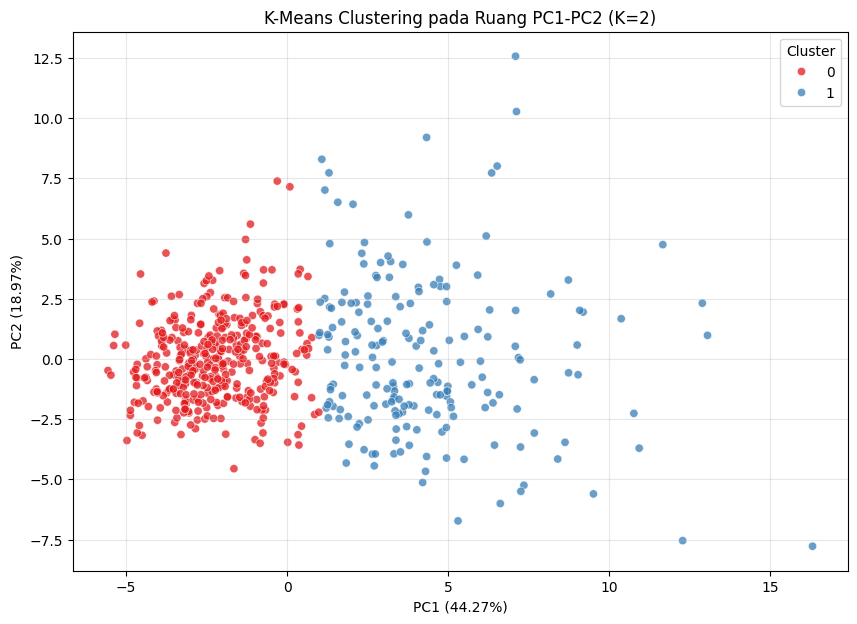

In [19]:
pca_cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.75
)

plt.title(
    f"K-Means Clustering pada Ruang PC1-PC2 "
    f"(K={best_k_silhouette})"
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)

plt.grid(alpha=0.3)
plt.show()


In [20]:
# Profil cluster: rata-rata tiap variabel (nilai asli) dan rasio antar cluster
cluster_profile = X.groupby(cluster_labels).mean().T
cluster_profile.columns = [f"Cluster {c}" for c in cluster_profile.columns]
if best_k == 2:
    cluster_profile["Rasio (C1/C0)"] = cluster_profile["Cluster 1"] / cluster_profile["Cluster 0"]

print("PROFIL CLUSTER (RATA-RATA NILAI ASLI):")
display(cluster_profile.round(4))

PROFIL CLUSTER (RATA-RATA NILAI ASLI):


,Cluster 0,Cluster 1,Rasio (C1/C0)
mean radius,12.4267,17.4145,1.4014
mean texture,18.2624,21.2753,1.1650
mean perimeter,79.8201,115.4529,1.4464
mean area,486.7723,979.8572,2.0130
mean smoothness,0.0920,0.1048,1.1393
mean compactness,0.0766,0.1580,2.0630
mean concavity,0.0427,0.1779,4.1694
mean concave points,0.0262,0.0929,3.5527
mean symmetry,0.1727,0.1975,1.1438
mean fractal dimension,0.0617,0.0648,1.0500


In [21]:
# Validasi eksternal: bandingkan cluster dengan diagnosis (label tidak dipakai saat clustering)
from sklearn.metrics import adjusted_rand_score

crosstab = pd.crosstab(
    pd.Series(cluster_labels, name="Cluster"),
    pd.Series(y, name="Diagnosis").map({0: "malignant", 1: "benign"})
)
display(crosstab)
print("Adjusted Rand Index :", round(adjusted_rand_score(y, cluster_labels), 3))

Diagnosis,benign,malignant
Cluster,,
0,339,36
1,18,176


Adjusted Rand Index : 0.654
